# CS3807 – Deep Learning Laboratory
## Experiment 4: Comparative Study of Deep CNN Architectures Using Transfer Learning

**Shiv Nadar University Chennai | B.Tech AI & Data Science | Semester V**

This notebook implements the full lab manual for Experiment 4:

1. Dataset preparation (CIFAR-10)
2. Transfer learning with a pretrained CNN (VGG16 / ResNet50 / MobileNetV2 / EfficientNetB0)
3. Model training and fine-tuning
4. Model evaluation (accuracy, precision, recall, F1, confusion matrix)
5. A from-scratch **LeNet-5** baseline for comparison
6. Architecture comparison (LeNet-5, AlexNet, VGG16, GoogleNet, ResNet50)
7. A lightweight hyperparameter study
8. Discussion question answers (draft — personalize with your own results)

> **How to run in Colab:** `Runtime → Change runtime type → GPU (T4)`, then `Runtime → Run all`.
> All plots that belong together (e.g. accuracy/loss curves) are drawn as **subplots** in a single figure so the report stays compact.


## 0. Setup

In [ ]:
# If running in Colab, TensorFlow is preinstalled. This just confirms the version & GPU.
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU available:", bool(gpus), gpus)


TensorFlow version: 2.20.0
GPU available: True [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, Model, Input
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]


## Task 1: Dataset Preparation

Load CIFAR-10, normalize pixel values to `[0, 1]`, display sample images and print dataset dimensions.


In [ ]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = cifar10.load_data()

# Keep an un-normalized float32 copy (0-255) for transfer-learning preprocessing later,
# and a normalized [0,1] copy for display / the LeNet-5 baseline.
x_train_raw = x_train_raw.astype("float32")
x_test_raw  = x_test_raw.astype("float32")

x_train_norm = x_train_raw / 255.0
x_test_norm  = x_test_raw / 255.0

y_train = y_train_raw.flatten()
y_test  = y_test_raw.flatten()

y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

print("Training images:", x_train_norm.shape, " Training labels:", y_train.shape)
print("Testing images :", x_test_norm.shape,  " Testing labels :", y_test.shape)
print("Pixel value range after normalization: [%.2f, %.2f]" % (x_train_norm.min(), x_train_norm.max()))


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4031s 24us/step
Training images: (50000, 32, 32, 3)  Training labels: (50000,)
Testing images : (10000, 32, 32, 3)  Testing labels : (10000,)
Pixel value range after normalization: [0.00, 1.00]


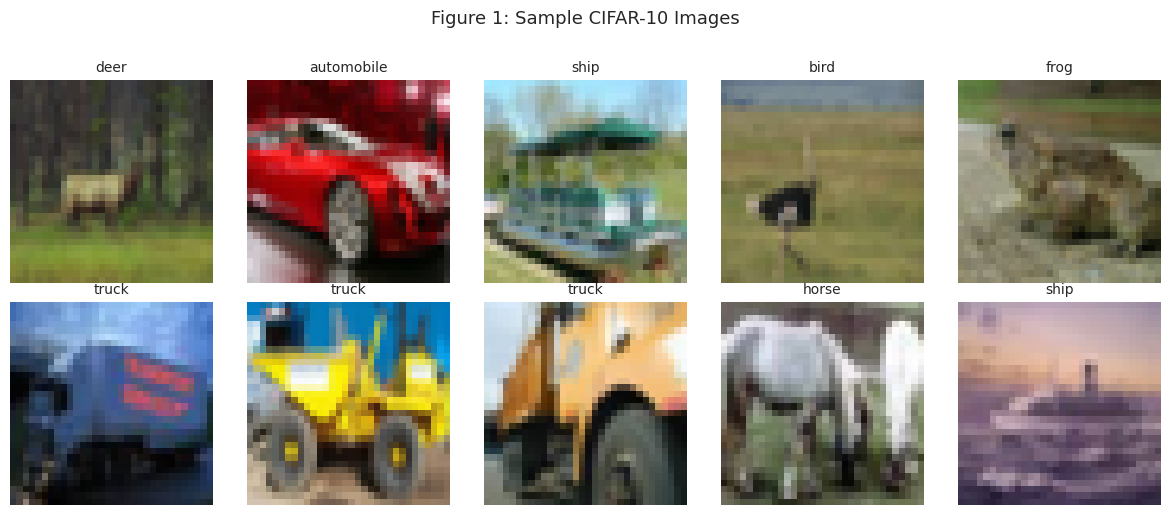

In [ ]:
# Sample CIFAR-10 images -- shown as a single figure with subplots
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(x_train_norm), 10, replace=False)

for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(x_train_norm[idx])
    ax.set_title(CLASS_NAMES[y_train[idx]], fontsize=10)
    ax.axis("off")

fig.suptitle("Figure 1: Sample CIFAR-10 Images", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


**Inference (edit this):** _CIFAR-10 contains 32×32 RGB images across 10 balanced classes. The low
resolution makes fine-grained features (e.g. cat vs. dog) harder to distinguish, which is why deeper
pretrained features from transfer learning are expected to help._

## Task 2: Transfer Learning — Model Setup

Choose a pretrained backbone (as required by the lab manual: VGG16, ResNet50, MobileNetV2 or
EfficientNetB0), remove its classifier, freeze the convolutional base, and attach a new
GlobalAveragePooling → Dense(ReLU) → Dense(Softmax) head.

> **Tip:** `MobileNetV2` is the fastest to train on Colab's free GPU/CPU. Switch `MODEL_NAME` to
> `"VGG16"` or `"ResNet50"` to match your assigned architecture — everything below adapts automatically.


In [ ]:
# ------------------------- CONFIGURATION -------------------------
MODEL_NAME   = "VGG16"     # one of: "VGG16", "ResNet50", "MobileNetV2", "EfficientNetB0"
IMG_SIZE     = 96          # input resolution fed to the pretrained backbone
DENSE_UNITS  = 256
BATCH_SIZE   = 32
LEARNING_RATE = 0.001
EPOCHS_HEAD      = 10       # Task 3: train the new classifier head
EPOCHS_FINETUNE  = 6        # Task 4: fine-tune the last conv block
UNFREEZE_LAST_N  = 20       # how many of the base model's final layers to unfreeze
VAL_SPLIT = 5000            # images held out from the training set for validation
# -------------------------------------------------------------------

from tensorflow.keras.applications import vgg16, resnet50, mobilenet_v2, efficientnet

BASE_MODELS = {
    "VGG16":          (tf.keras.applications.VGG16,          vgg16.preprocess_input),
    "ResNet50":        (tf.keras.applications.ResNet50,        resnet50.preprocess_input),
    "MobileNetV2":     (tf.keras.applications.MobileNetV2,     mobilenet_v2.preprocess_input),
    "EfficientNetB0":  (tf.keras.applications.EfficientNetB0,  efficientnet.preprocess_input),
}

base_fn, preprocess_fn = BASE_MODELS[MODEL_NAME]
print("Selected backbone:", MODEL_NAME)


Selected backbone: VGG16


In [ ]:
def make_dataset(x, y_cat, preprocess_fn, img_size=IMG_SIZE, batch_size=BATCH_SIZE,
                  shuffle=False, augment=False, seed=SEED):
    ds = tf.data.Dataset.from_tensor_slices((x, y_cat))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(x), 10000), seed=seed)

    def _resize_preprocess(img, label):
        img = tf.image.resize(img, (img_size, img_size))
        img = preprocess_fn(img)
        return img, label

    ds = ds.map(_resize_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def _aug(img, label):
            img = tf.image.random_flip_left_right(img)
            return img, label
        ds = ds.map(_aug, num_parallel_calls=tf.data.AUTOTUNE)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


# Hold out a validation split from the training data
x_tr, x_val = x_train_raw[:-VAL_SPLIT], x_train_raw[-VAL_SPLIT:]
y_tr, y_val = y_train_cat[:-VAL_SPLIT], y_train_cat[-VAL_SPLIT:]

train_ds = make_dataset(x_tr,  y_tr,  preprocess_fn, shuffle=True, augment=True)
val_ds   = make_dataset(x_val, y_val, preprocess_fn)
test_ds  = make_dataset(x_test_raw, y_test_cat, preprocess_fn)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches  :", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches :", tf.data.experimental.cardinality(test_ds).numpy())


Train batches: 1407
Val batches  : 157
Test batches : 313


In [ ]:
def build_transfer_model(base_fn, img_size=IMG_SIZE, dense_units=DENSE_UNITS, num_classes=10):
    base = base_fn(include_top=False, weights="imagenet", input_shape=(img_size, img_size, 3))
    base.trainable = False  # Step 3: freeze convolutional base

    inputs = Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)           # Step 4
    x = layers.Dense(dense_units, activation="relu")(x)  # Step 5
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)  # Step 6

    model = Model(inputs, outputs, name=f"{MODEL_NAME}_transfer")
    return model, base

model, base_model = build_transfer_model(base_fn)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss="categorical_crossentropy",
              metrics=["accuracy"])
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "VGG16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Task 3: Model Training (feature-extraction phase)

Trains only the new classifier head; the pretrained convolutional base stays frozen.


In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=4, restore_best_weights=True
)

start_time = time.time()
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=[early_stop],
    verbose=1,
)
head_training_time = time.time() - start_time
print(f"Head-training time: {head_training_time:.1f} s")


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.7321 - loss: 0.9125 - val_accuracy: 0.8058 - val_loss: 0.5630
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 76s 54ms/step - accuracy: 0.8061 - loss: 0.5689 - val_accuracy: 0.8232 - val_loss: 0.5206
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 53ms/step - accuracy: 0.8251 - loss: 0.5156 - val_accuracy: 0.8174 - val_loss: 0.5266
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 54ms/step - accuracy: 0.8354 - loss: 0.4780 - val_accuracy: 0.8330 - val_loss: 0.5001
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 76s 54ms/step - accuracy: 0.8469 - loss: 0.4448 - val_accuracy: 0.8328 - val_loss: 0.5202
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 53ms/step - accuracy: 0.8534 - loss: 0.4212 - val_accuracy: 0.8294 - val_loss: 0.5166
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 54ms/step - accuracy: 0.8623 - loss: 0.3980 - val_accuracy: 0.8330 - val_loss: 0.5380
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 54ms/step - accuracy: 0.8697 -

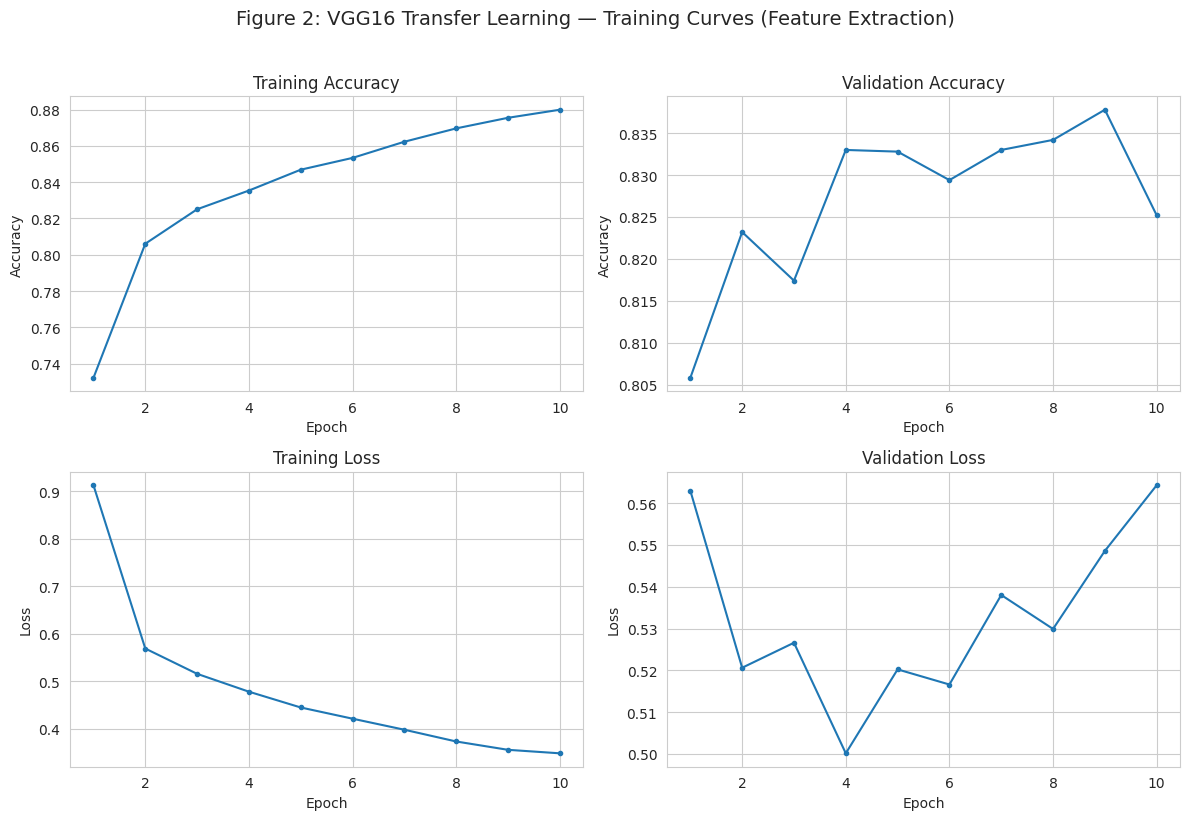

In [ ]:
def plot_training_curves(histories, labels, title, phase_boundaries=None):
    '''histories: list of keras History.history dicts to concatenate along epochs.
    labels: list of same length used only for the suptitle context.
    phase_boundaries: list of epoch indices (x-axis) to draw a vertical line at
                       (e.g. where fine-tuning starts).'''
    combined = {}
    for key in histories[0].keys():
        combined[key] = sum((h[key] for h in histories), [])

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    metrics = [("accuracy", "Training Accuracy", axes[0, 0]),
               ("val_accuracy", "Validation Accuracy", axes[0, 1]),
               ("loss", "Training Loss", axes[1, 0]),
               ("val_loss", "Validation Loss", axes[1, 1])]

    for key, subtitle, ax in metrics:
        ax.plot(range(1, len(combined[key]) + 1), combined[key], marker="o", markersize=3)
        ax.set_title(subtitle)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(key.split("_")[-1].capitalize())
        if phase_boundaries:
            for b in phase_boundaries:
                ax.axvline(b, color="red", linestyle="--", alpha=0.6)

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    return combined

combined_history = plot_training_curves(
    [history_head.history], ["head"],
    f"Figure 2: {MODEL_NAME} Transfer Learning — Training Curves (Feature Extraction)"
)


**Inference (edit this):** _Training accuracy should rise quickly since only the small dense head
is being trained; validation accuracy typically plateaus once the frozen features stop improving
further. If train/val curves diverge, that indicates overfitting of the head._

## Task 4: Fine-Tuning

Unfreeze the last convolutional block of the backbone and continue training with a much smaller
learning rate so the pretrained weights are only nudged, not destroyed.


In [ ]:
base_model.trainable = True
fine_tune_at = max(0, len(base_model.layers) - UNFREEZE_LAST_N)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Unfroze the last {trainable_count} / {len(base_model.layers)} layers of {MODEL_NAME}.")

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE / 100),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

start_time = time.time()
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINETUNE,
    callbacks=[early_stop],
    verbose=1,
)
finetune_training_time = time.time() - start_time
total_training_time = head_training_time + finetune_training_time
print(f"Fine-tuning time: {finetune_training_time:.1f} s | Total: {total_training_time:.1f} s")


Unfroze the last 19 / 19 layers of VGG16.
Epoch 1/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 239s 157ms/step - accuracy: 0.8943 - loss: 0.3125 - val_accuracy: 0.8868 - val_loss: 0.3474
Epoch 2/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 209s 149ms/step - accuracy: 0.9254 - loss: 0.2178 - val_accuracy: 0.9116 - val_loss: 0.2901
Epoch 3/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 208s 148ms/step - accuracy: 0.9428 - loss: 0.1626 - val_accuracy: 0.9154 - val_loss: 0.2849
Epoch 4/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 207s 147ms/step - accuracy: 0.9549 - loss: 0.1293 - val_accuracy: 0.9256 - val_loss: 0.2431
Epoch 5/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 208s 148ms/step - accuracy: 0.9630 - loss: 0.1055 - val_accuracy: 0.9194 - val_loss: 0.2836
Epoch 6/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 212s 150ms/step - accuracy: 0.9703 - loss: 0.0861 - val_accuracy: 0.9214 - val_loss: 0.2853
Fine-tuning time: 1284.1 s | Total: 2041.4 s


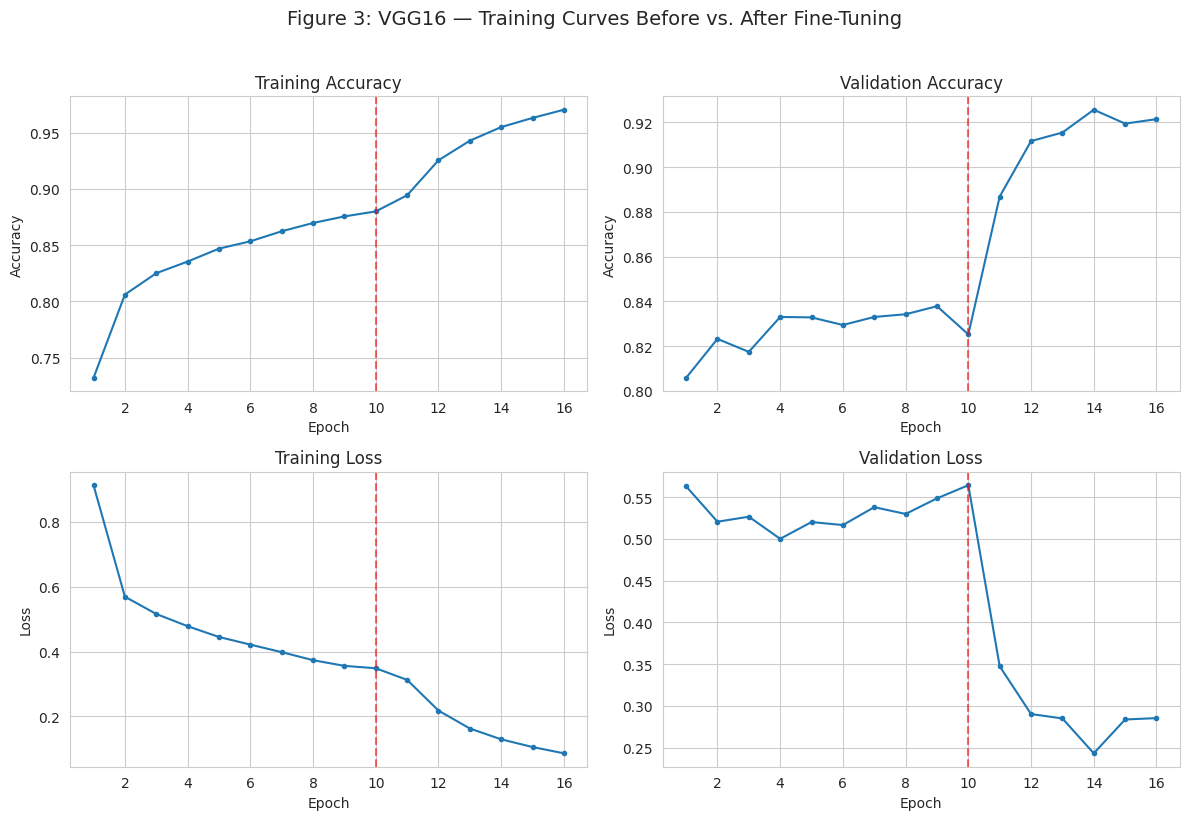

Best validation accuracy BEFORE fine-tuning: 0.8378
Best validation accuracy AFTER  fine-tuning: 0.9256
Improvement: 8.78 percentage points


In [ ]:
combined_history_ft = plot_training_curves(
    [history_head.history, history_finetune.history],
    ["head", "fine-tune"],
    f"Figure 3: {MODEL_NAME} — Training Curves Before vs. After Fine-Tuning",
    phase_boundaries=[len(history_head.history["accuracy"])],
)

best_val_before = max(history_head.history["val_accuracy"])
best_val_after  = max(history_finetune.history["val_accuracy"])
print(f"Best validation accuracy BEFORE fine-tuning: {best_val_before:.4f}")
print(f"Best validation accuracy AFTER  fine-tuning: {best_val_after:.4f}")
print(f"Improvement: {(best_val_after - best_val_before) * 100:.2f} percentage points")


**Inference (edit this):** _The red dashed line marks where fine-tuning begins. A jump/dip right
after it is normal (the optimizer state resets); accuracy should recover and typically exceed the
feature-extraction-only result within a few epochs, since the backbone's late layers can now adapt to
CIFAR-10's specific features._

## Task 5: Model Evaluation

Accuracy, Precision, Recall, F1-score, Confusion Matrix and Classification Report on the CIFAR-10 test set.


In [ ]:
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test  # test_ds was built without shuffling, so order matches y_test

test_accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")
total_params = model.count_params()

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro)   : {recall:.4f}")
print(f"F1-score (macro) : {f1:.4f}")
print(f"Total Parameters : {total_params:,}")
print()
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Test Accuracy : 0.9173
Precision (macro): 0.9171
Recall (macro)   : 0.9173
F1-score (macro) : 0.9170
Total Parameters : 14,848,586

Classification Report:
              precision    recall  f1-score   support

    airplane       0.92      0.93      0.93      1000
  automobile       0.95      0.96      0.96      1000
        bird       0.94      0.89      0.91      1000
         cat       0.84      0.82      0.83      1000
        deer       0.91      0.90      0.91      1000
         dog       0.87      0.85      0.86      1000
        frog       0.92      0.96      0.94      1000
       horse       0.91      0.95      0.93      1000
        ship       0.94      0.97      0.95      1000
       truck       0.96      0.94      0.95      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



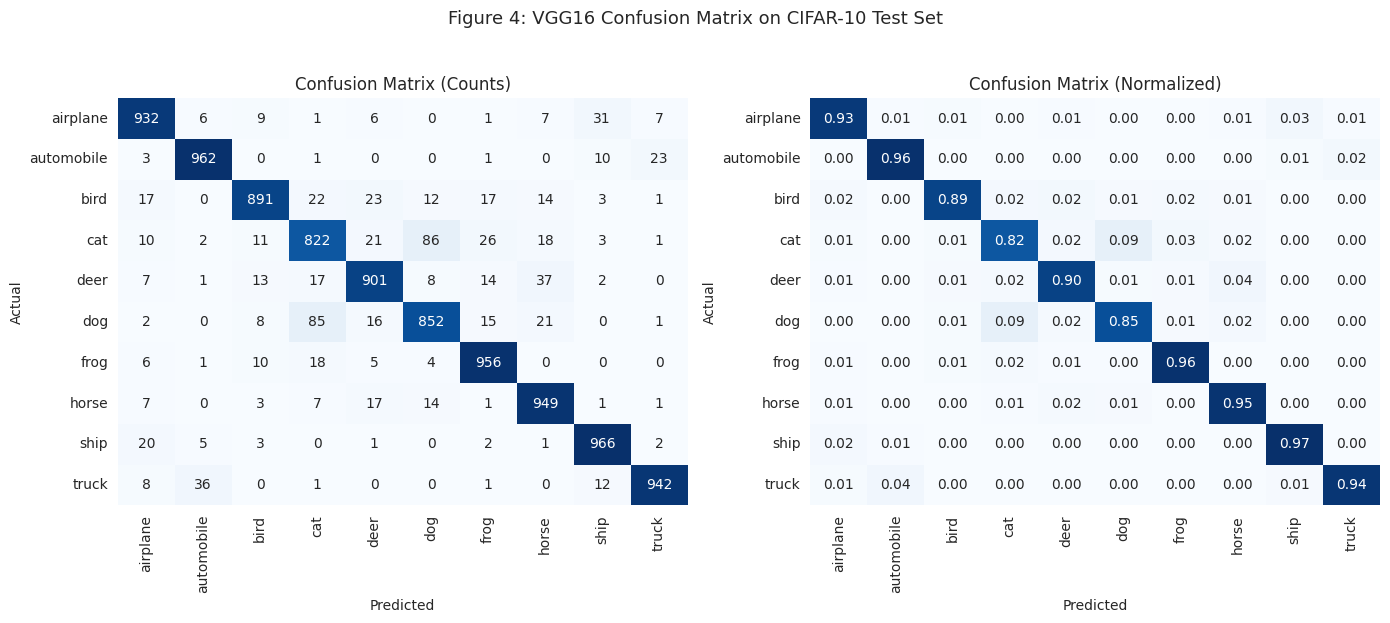

In [ ]:
# Confusion Matrix + normalized confusion matrix as subplots
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=axes[0], cbar=False)
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=axes[1], cbar=False)
axes[1].set_title("Confusion Matrix (Normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

fig.suptitle(f"Figure 4: {MODEL_NAME} Confusion Matrix on CIFAR-10 Test Set", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()


**Inference (edit this):** _Look for classes that are frequently confused with each other (e.g.
cat vs. dog, automobile vs. truck) — these visually or semantically similar classes are the hardest
for the model and are natural candidates to discuss in your report._

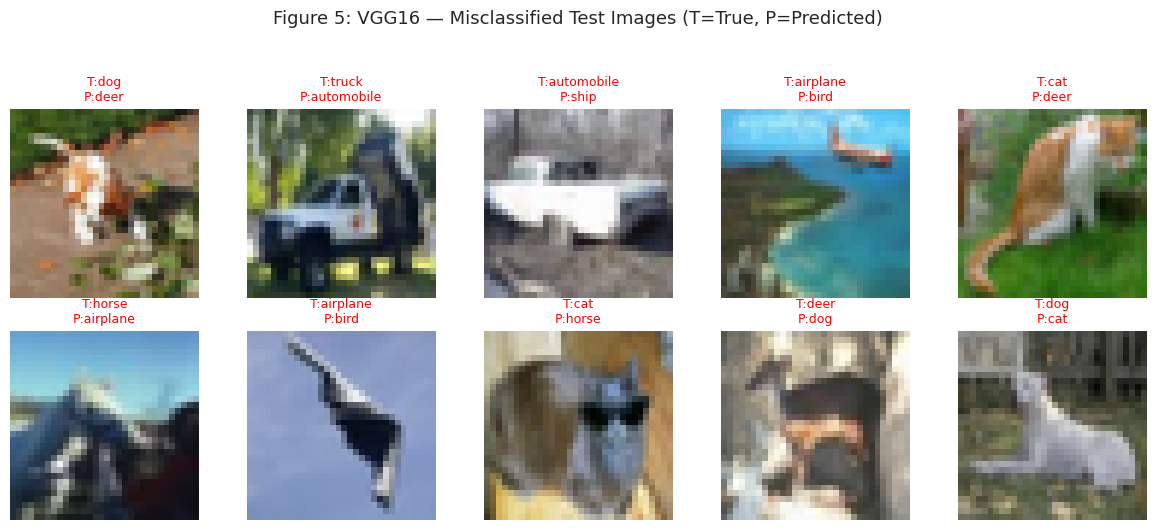

Total misclassified: 827 / 10000 (8.27%)


In [ ]:
# Misclassified images (optional mandatory plot #7)
mis_idx = np.where(y_pred != y_true)[0]
n_show = min(10, len(mis_idx))
show_idx = np.random.default_rng(SEED).choice(mis_idx, n_show, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, show_idx):
    ax.imshow(x_test_norm[idx])
    ax.set_title(f"T:{CLASS_NAMES[y_true[idx]]}\nP:{CLASS_NAMES[y_pred[idx]]}", fontsize=9, color="red")
    ax.axis("off")

fig.suptitle(f"Figure 5: {MODEL_NAME} — Misclassified Test Images (T=True, P=Predicted)", y=1.05, fontsize=13)
plt.tight_layout()
plt.show()
print(f"Total misclassified: {len(mis_idx)} / {len(y_true)} "
      f"({100 * len(mis_idx) / len(y_true):.2f}%)")


## Additional Baseline: LeNet-5 (trained from scratch)

Built purely from the original LeNet-5 architecture so we have a real, measured data point for the
architecture-comparison table below (not just literature numbers).


In [ ]:
def build_lenet5(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(6, (5, 5), activation="tanh", padding="same"),
        layers.AveragePooling2D(pool_size=(2, 2)),
        layers.Conv2D(16, (5, 5), activation="tanh"),
        layers.AveragePooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(120, activation="tanh"),
        layers.Dense(84, activation="tanh"),
        layers.Dense(num_classes, activation="softmax"),
    ], name="LeNet5")
    return model

lenet_model = build_lenet5()
lenet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                     loss="categorical_crossentropy", metrics=["accuracy"])
lenet_model.summary()

Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,126 (324.71 KB)

 Trainable params: 83,126 (324.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
LENET_EPOCHS = 15

start_time = time.time()
lenet_history = lenet_model.fit(
    x_tr / 255.0, y_tr,
    validation_data=(x_val / 255.0, y_val),
    epochs=LENET_EPOCHS,
    batch_size=64,
    verbose=1,
)
lenet_training_time = time.time() - start_time

lenet_test_loss, lenet_test_acc = lenet_model.evaluate(x_test_norm, y_test_cat, verbose=0)
lenet_params = lenet_model.count_params()
print(f"LeNet-5 test accuracy: {lenet_test_acc:.4f} | params: {lenet_params:,} | "
      f"training time: {lenet_training_time:.1f}s")


Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.3724 - loss: 1.7869 - val_accuracy: 0.3938 - val_loss: 1.7196
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4381 - loss: 1.5921 - val_accuracy: 0.4456 - val_loss: 1.5572
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4832 - loss: 1.4614 - val_accuracy: 0.4814 - val_loss: 1.4627
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5132 - loss: 1.3741 - val_accuracy: 0.4990 - val_loss: 1.4122
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5378 - loss: 1.3086 - val_accuracy: 0.5162 - val_loss: 1.3714
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5563 - loss: 1.2530 - val_accuracy: 0.5258 - val_loss: 1.3474
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5728 - loss: 1.2057 - val_accuracy: 0.5286 - val_loss: 1.3398
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5869 - loss: 1.1645 - val_accuracy: 0

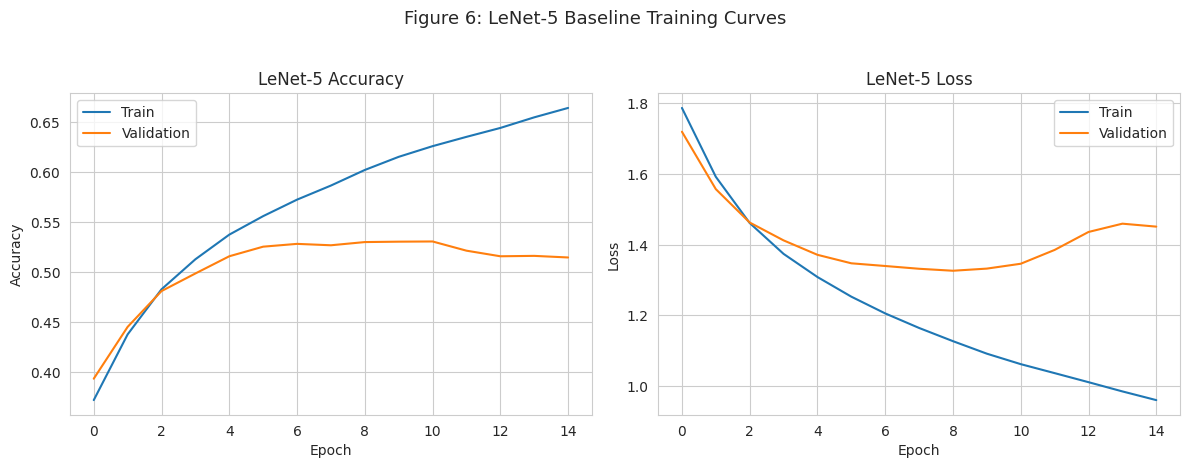

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(lenet_history.history["accuracy"], label="Train")
axes[0].plot(lenet_history.history["val_accuracy"], label="Validation")
axes[0].set_title("LeNet-5 Accuracy")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(lenet_history.history["loss"], label="Train")
axes[1].plot(lenet_history.history["val_loss"], label="Validation")
axes[1].set_title("LeNet-5 Loss")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

fig.suptitle("Figure 6: LeNet-5 Baseline Training Curves", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()


**Inference (edit this):** _LeNet-5 has far fewer parameters and no pretrained knowledge, so
expect noticeably lower accuracy than the transfer-learning model — this gap is the empirical
evidence for why transfer learning helps on small/simple datasets like CIFAR-10._

## 18. Comparison of CNN Architectures

LeNet-5 and the transfer-learning model above are **measured** in this notebook. AlexNet and
GoogleNet are not trained here (to keep runtime reasonable on Colab); their depth/parameter figures
are taken from the lab manual / original papers and marked as *reference*. To get real numbers for
them, add training cells the same way as the LeNet-5 section, or re-run Task 2 with
`MODEL_NAME = "ResNet50"`.


In [ ]:
comparison_data = [
    {"Model": "LeNet-5",             "Depth": 7,  "Parameters": lenet_params,        "Accuracy (%)": lenet_test_acc * 100,        "Training Time (s)": lenet_training_time,   "Source": "measured"},
    {"Model": "AlexNet",             "Depth": 8,  "Parameters": 61_000_000,          "Accuracy (%)": None,                        "Training Time (s)": None,                  "Source": "reference (lab manual)"},
    {"Model": "VGG16",               "Depth": 16, "Parameters": 138_000_000,         "Accuracy (%)": None,                        "Training Time (s)": None,                  "Source": "reference (lab manual)"},
    {"Model": "GoogleNet",           "Depth": 22, "Parameters": 6_800_000,           "Accuracy (%)": None,                        "Training Time (s)": None,                  "Source": "reference (lab manual)"},
    {"Model": "ResNet50",            "Depth": 50, "Parameters": 25_600_000,          "Accuracy (%)": None,                        "Training Time (s)": None,                  "Source": "reference (lab manual)"},
    {"Model": f"{MODEL_NAME} (this run)", "Depth": len(base_model.layers), "Parameters": total_params, "Accuracy (%)": test_accuracy * 100, "Training Time (s)": total_training_time, "Source": "measured"},
]

comparison_df = pd.DataFrame(comparison_data)
comparison_df


,Model,Depth,Parameters,Accuracy (%),Training Time (s),Source
0,LeNet-5,7,83126,51.700002,58.134500,measured
1,AlexNet,8,61000000,NaN,NaN,reference (lab manual)
2,VGG16,16,138000000,NaN,NaN,reference (lab manual)
3,GoogleNet,22,6800000,NaN,NaN,reference (lab manual)
4,ResNet50,50,25600000,NaN,NaN,reference (lab manual)
5,VGG16 (this run),19,14848586,91.730000,2041.440615,measured


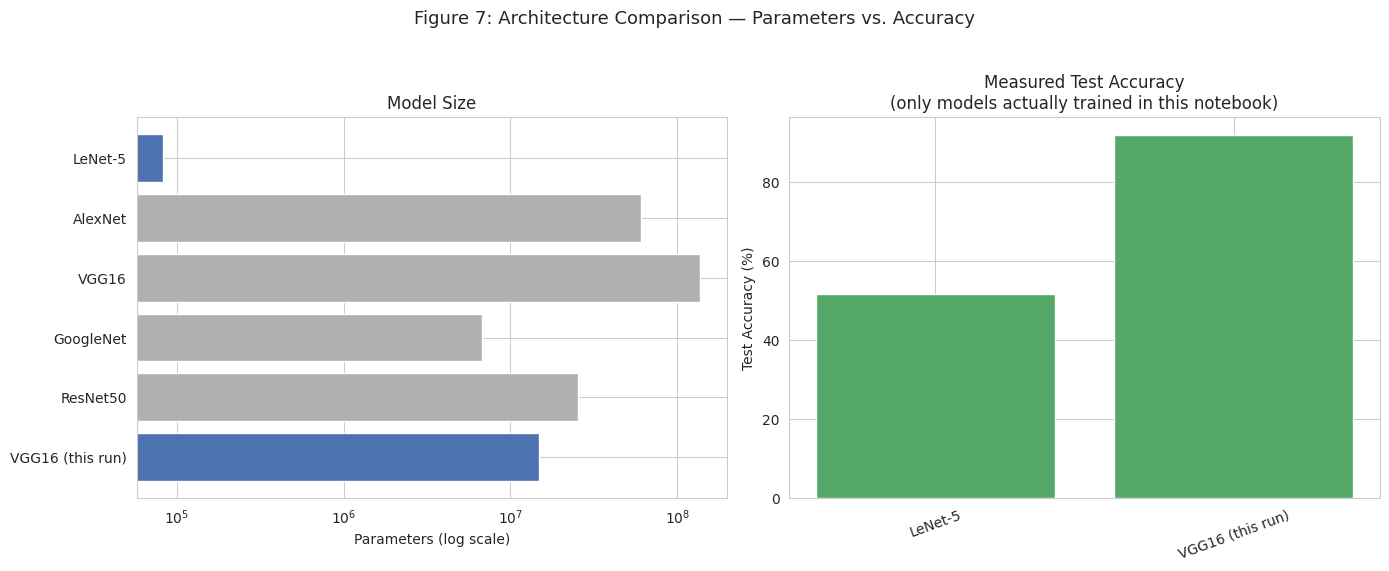

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

colors = ["#4C72B0" if s == "measured" else "#B0B0B0" for s in comparison_df["Source"]]
axes[0].barh(comparison_df["Model"], comparison_df["Parameters"], color=colors)
axes[0].set_xscale("log")
axes[0].set_xlabel("Parameters (log scale)")
axes[0].set_title("Model Size")
axes[0].invert_yaxis()

acc_df = comparison_df.dropna(subset=["Accuracy (%)"])
axes[1].bar(acc_df["Model"], acc_df["Accuracy (%)"], color="#55A868")
axes[1].set_ylabel("Test Accuracy (%)")
axes[1].set_title("Measured Test Accuracy\n(only models actually trained in this notebook)")
axes[1].tick_params(axis="x", rotation=20)

fig.suptitle("Figure 7: Architecture Comparison — Parameters vs. Accuracy", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()


**Inference (edit this):** _Grey bars are literature reference values (not trained here). Note
how GoogleNet has far fewer parameters than VGG16 despite being deeper — a direct result of Inception
modules and 1×1 convolutions reducing parameter count._

## 16. Hyperparameter Study (lightweight demo)

The full grid in the lab manual (learning rate × batch size × epochs × optimizer × dense units ×
frozen layers) is expensive to run exhaustively on Colab. This cell demonstrates the **methodology**
on a small subset of the data with a couple of learning-rate / batch-size combinations, training only
the classifier head (frozen backbone) for a few epochs each. Expand `HP_LEARNING_RATES`,
`HP_BATCH_SIZES`, or `HP_EPOCHS` if you have more GPU time available.


In [ ]:
HP_SUBSET_SIZE   = 5000   # smaller subset purely for a fast demonstration
HP_LEARNING_RATES = [0.001, 0.0001]
HP_BATCH_SIZES    = [32, 64]
HP_EPOCHS         = 3

hp_x = x_tr[:HP_SUBSET_SIZE]
hp_y = y_tr[:HP_SUBSET_SIZE]
hp_x_val = x_val[:1000]
hp_y_val = y_val[:1000]

hp_results = []
for lr in HP_LEARNING_RATES:
    for bs in HP_BATCH_SIZES:
        hp_train_ds = make_dataset(hp_x, hp_y, preprocess_fn, batch_size=bs, shuffle=True)
        hp_val_ds   = make_dataset(hp_x_val, hp_y_val, preprocess_fn, batch_size=bs)

        hp_model, hp_base = build_transfer_model(base_fn)
        hp_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                          loss="categorical_crossentropy", metrics=["accuracy"])
        hp_hist = hp_model.fit(hp_train_ds, validation_data=hp_val_ds,
                                epochs=HP_EPOCHS, verbose=0)

        best_acc = max(hp_hist.history["val_accuracy"])
        hp_results.append({"learning_rate": lr, "batch_size": bs, "val_accuracy": best_acc})
        print(f"lr={lr:<8} batch_size={bs:<4} -> best val_accuracy={best_acc:.4f}")

hp_df = pd.DataFrame(hp_results)
hp_df


lr=0.001    batch_size=32   -> best val_accuracy=0.7750
lr=0.001    batch_size=64   -> best val_accuracy=0.7570
lr=0.0001   batch_size=32   -> best val_accuracy=0.6860
lr=0.0001   batch_size=64   -> best val_accuracy=0.6210


,learning_rate,batch_size,val_accuracy
0,0.0010,32,0.775
1,0.0010,64,0.757
2,0.0001,32,0.686
3,0.0001,64,0.621


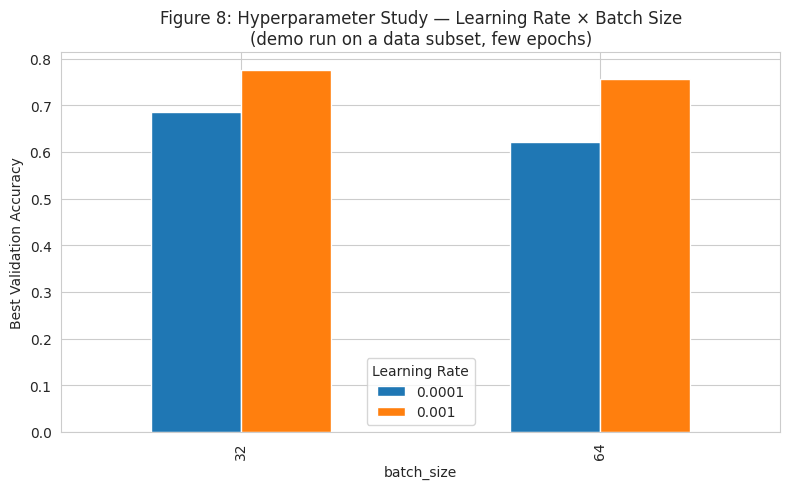

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot = hp_df.pivot(index="batch_size", columns="learning_rate", values="val_accuracy")
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("Best Validation Accuracy")
ax.set_title("Figure 8: Hyperparameter Study — Learning Rate × Batch Size\n"
             "(demo run on a data subset, few epochs)")
ax.legend(title="Learning Rate")
plt.tight_layout()
plt.show()


**Inference (edit this):** _Lower learning rates are generally more stable but may need more
epochs to converge; larger batch sizes give smoother gradient estimates but fewer weight updates per
epoch. Re-run with `HP_EPOCHS` increased and the full training set for a report-quality comparison._

## 18.1 / 18.2 Auto-Filled Results Tables

These reproduce the lab manual's result tables using the values measured above.


In [ ]:
performance_metrics_df = pd.DataFrame({
    "Metric": ["Training Accuracy", "Testing Accuracy", "Precision", "Recall", "F1-score",
               "Training Time (s)", "Total Parameters"],
    "Value": [
        f"{max(history_finetune.history['accuracy']):.4f}",
        f"{test_accuracy:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        f"{total_training_time:.1f}",
        f"{total_params:,}",
    ]
})
print(f"Performance metrics for backbone: {MODEL_NAME}")
performance_metrics_df


Performance metrics for backbone: VGG16


,Metric,Value
0,Training Accuracy,0.9703
1,Testing Accuracy,0.9173
2,Precision,0.9171
3,Recall,0.9173
4,F1-score,0.9170
5,Training Time (s),2041.4
6,Total Parameters,"14,848,586"


In [ ]:
comparison_df

,Model,Depth,Parameters,Accuracy (%),Training Time (s),Source
0,LeNet-5,7,83126,51.700002,58.134500,measured
1,AlexNet,8,61000000,NaN,NaN,reference (lab manual)
2,VGG16,16,138000000,NaN,NaN,reference (lab manual)
3,GoogleNet,22,6800000,NaN,NaN,reference (lab manual)
4,ResNet50,50,25600000,NaN,NaN,reference (lab manual)
5,VGG16 (this run),19,14848586,91.730000,2041.440615,measured


## 19. Discussion Questions

Draft answers below — **personalize items 9 and 10 with numbers from your own run**, and adapt the
others in your own words before submitting.

**1. Why is AlexNet considered a breakthrough in deep learning?**
It was the first architecture to win ImageNet by a large margin using ReLU activations (faster
convergence than tanh/sigmoid), Dropout (reduced overfitting), and GPU-based training (made deep
CNNs computationally practical for the first time).

**2. Why does VGG16 use only 3×3 convolution filters?**
Stacking multiple 3×3 filters gives the same effective receptive field as a larger filter (e.g. two
3×3 layers ≈ one 5×5 layer) while using fewer parameters and adding more non-linearities (ReLU after
each layer), which improves representational power.

**3. Explain the advantages of the Inception module.**
It applies multiple filter sizes (1×1, 3×3, 5×5) and pooling in parallel and concatenates the
results, capturing multi-scale features in a single layer. 1×1 convolutions before larger filters
act as a "bottleneck" that reduces channel depth and computational cost before the expensive
operations.

**4. What is the purpose of residual learning?**
It lets a layer learn a residual function F(x) = H(x) − x instead of the full mapping H(x) directly.
The skip connection (output = F(x) + x) gives gradients a direct path back through the network,
which prevents vanishing gradients and makes very deep networks (50+ layers) trainable.

**5. Differentiate LeNet and ResNet.**
LeNet-5 (1998) is a shallow 7-layer network (~60K params) designed for small grayscale digit images
with no skip connections. ResNet (2015) is 50+ layers deep (~25.6M params for ResNet50), uses skip
connections to enable very deep training, and is designed for large-scale natural image
classification (ImageNet).

**6. What is Transfer Learning?**
Reusing a model already trained on a large dataset (e.g. ImageNet) as a starting point for a new,
often smaller, task/dataset — instead of training a network from randomly initialized weights.

**7. Why is fine tuning required?**
Frozen pretrained features are general-purpose (edges, textures, shapes) but not specialized to the
new dataset's exact classes. Fine-tuning (unfreezing some later layers and training with a small
learning rate) lets those layers adapt to task-specific patterns, usually improving accuracy further.

**8. Explain the difference between dilated convolution and transpose convolution.**
Dilated (atrous) convolution inserts gaps between kernel elements to enlarge the receptive field
*without* increasing parameters or changing output resolution — useful for tasks like semantic
segmentation. Transpose convolution does learnable *upsampling* — it increases the spatial size of
the feature map (the opposite of pooling) — used in generation/decoder tasks like GANs and
autoencoders.

**9. Why do pretrained models converge faster?** *(personalize with your plots)*
Their convolutional filters already encode useful low- and mid-level visual features learned from
millions of ImageNet images, so the network starts much closer to a good solution than random
initialization — only the new head (and, during fine-tuning, a few late layers) needs substantial
updates. This is visible in Figure 2, where validation accuracy rises sharply within the first few
epochs.

**10. Compare the computational complexity of LeNet and ResNet.** *(personalize with your measured numbers)*
LeNet-5 has ~60K parameters and trains in seconds/minutes on a CPU because of its shallow depth and
small input size. ResNet50 has ~25.6M parameters and 50 layers, requiring GPU acceleration and
substantially more FLOPs per forward/backward pass — but its skip connections make that extra depth
trainable, which is what buys the higher accuracy on complex image data.


## 20. Additional Exercises — Pointers

- **Ex 1/2 (VGG16 / ResNet50):** change `MODEL_NAME` in the config cell and re-run from Task 2 onward.
- **Ex 3 (Adam vs SGD):** in the hyperparameter cell, add an `optimizer` loop
  (`tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)` vs `Adam`).
- **Ex 4 (frozen vs fine-tuned):** already compared in Figure 3 / the "before vs after" printout.
- **Ex 5 (Precision/Recall/F1):** already computed in Task 5.
- **Ex 6 (LeNet vs AlexNet vs ResNet):** LeNet-5 is trained here; add analogous training cells for
  AlexNet (a simple 5-conv-layer CNN adapted for 32×32 input) and re-run Task 2 with
  `MODEL_NAME = "ResNet50"` to get all three measured.


## References

1. LeCun, Bottou, Bengio, Haffner — *Gradient-Based Learning Applied to Document Recognition*, IEEE, 1998.
2. Krizhevsky, Sutskever, Hinton — *ImageNet Classification with Deep CNNs*, NeurIPS, 2012.
3. Simonyan, Zisserman — *Very Deep Convolutional Networks for Large-Scale Image Recognition*, ICLR, 2015.
4. Szegedy et al. — *Going Deeper with Convolutions*, CVPR, 2015.
5. He, Zhang, Ren, Sun — *Deep Residual Learning for Image Recognition*, CVPR, 2016.
6. Goodfellow, Bengio, Courville — *Deep Learning*, MIT Press, 2016.
7. TensorFlow Docs: https://www.tensorflow.org
8. Keras Docs: https://keras.io
